In [2]:
from tiled.client import from_profile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
from datetime import datetime
import databroker
import matplotlib.ticker as ticker
# %matplotlib widget
import json


Pb L1 71c03eb6-c456-44c4-ab55-5f73140c7704 mono_e 15.673keV mono_b 13.9378deg und 16.9keV edge_lit 15.861keV
Pb L2 40d99a87-b530-4ee6-96d8-618161534648 mono_e 15.035keV mono_b 14.584deg und 20.3keV edge_lit 15.200keV
Se K a9e4d24b-7352-4171-9fef-bf206d9cf1c2  mono_e 12.539keV mono_b 17.573deg und 12.3keV edge_lit 12.658keV
Zn K afb28489-0ccf-4ab8-bab7-6c501d62cc5a  mono_e 9.594keV mono_b 23.242deg und 9.75keV edge_lit 9.659keV


00063462-d6d4-4f54-8a85-82fc8e254cd0   20 2026-03-18 13:28:02 rel_scan ['tetramm1']


/tmp/ipykernel_216841/3194353085.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_216841/3194353085.py:107: RuntimeWarning: divide by zero encountered in divide
  return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))
/tmp/ipykernel_216841/3194353085.py:107: RuntimeWarning: invalid value encountered in arcsin
  return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))


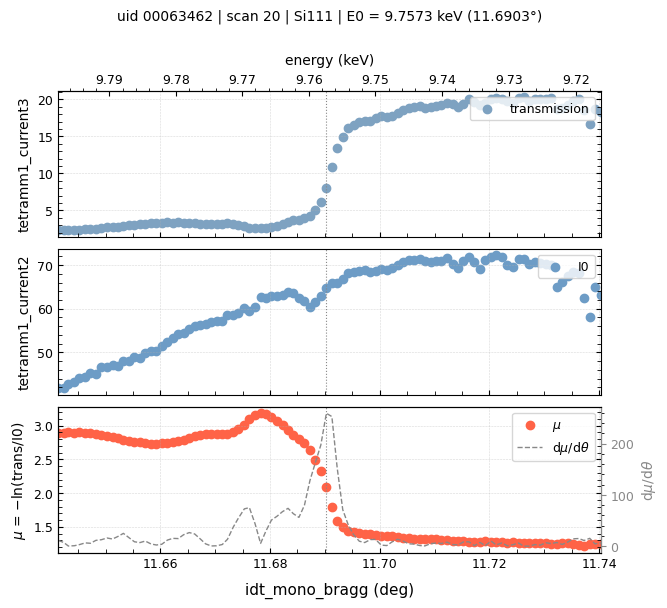

In [50]:
catalog = databroker.catalog["8idi_xpcs"]

runs_uids = list(catalog.search({}))

for uid in runs_uids[0:1]: # runs[0:1] selects most recent uid sent to databroker
    run = catalog[uid]
    start = run.metadata["start"]
    t = start.get("time", 0)
    dt = datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S") if t else "?"
    print(
        uid[:],
        str(start.get("scan_id","?")).rjust(4),
        dt,
        start.get("plan_name","unknown"),
        start.get("detectors", []),
    )

run = catalog[uid]
ds = run.primary.read()

fig, axes = plot_transmission(ds, scan_axis='idt_mono_bragg', silicon=111) # scan_axis could be idt_mono_bragg or idt_mono_energy
plt.show()


Pb L1   bragg=7.1520°  mono=15.8796 keV  lit=15.861 keV  offset=+18.6 eV
Pb L2   bragg=7.4620°  mono=15.2234 keV  lit=15.200 keV  offset=+23.4 eV
Se K    bragg=8.9780°  mono=12.6689 keV  lit=12.658 keV  offset=+10.9 eV
Zn K    bragg=11.8000°  mono=9.6679 keV  lit=9.659 keV  offset=+8.9 eV


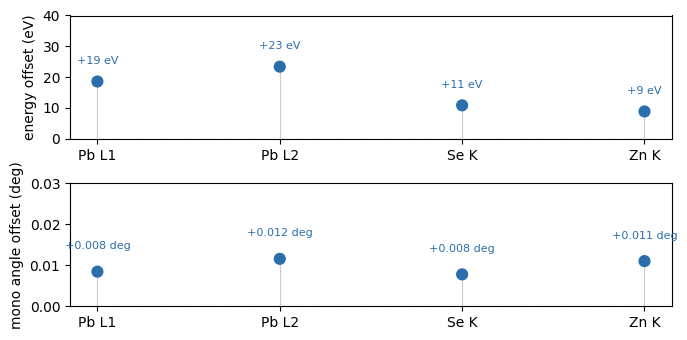

In [ ]:
### results from Si111 
edges = [
    {'label': 'Pb L1', 'bragg': 7.152, 'und': 15.94,  'uid': '12e50399', 'e_lit': 15.861},
    {'label': 'Pb L2', 'bragg': 7.462,  'und': 15.28,  'uid': 'af5e7ed0', 'e_lit': 15.200},
    {'label': 'Se K',  'bragg': 8.978,  'und': 12.3,  'uid': '707b4971', 'e_lit': 12.658},
    {'label': 'Zn K',  'bragg': 11.8,  'und':  9.75, 'uid': '96a300f5', 'e_lit':  9.659},
]

for e in edges:
    e['mono'] = bragg_to_energy(e['bragg'], silicon=111)
    e['bragg_lit'] = energy_to_bragg(e['e_lit'], silicon=111)

labels  = [e['label'] for e in edges]
offsets_e = [(e['mono'] - e['e_lit']) * 1000 for e in edges]  # eV
offsets_a = [(e['bragg_lit'] - e['bragg']) for e in edges] # angle

fig, [ax0, ax1] = plt.subplots(2, 1, figsize=(7, 3.5))

colors = ['#b84a2a' if o < 0 else '#2a6eab' for o in offsets_a]

ax0.scatter(range(len(edges)), offsets_e, s=60, color=colors, zorder=3)
ax0.axhline(0, color='#888', linewidth=0.8, linestyle='--')
for i, (o, e) in enumerate(zip(offsets_e, edges)):
    ax0.plot([i, i], [0, o], color='#ccc', linewidth=0.8, zorder=2)
    ax0.text(i, o + (5 if o >= 0 else -15), f"{o:+.0f} eV", ha='center', va='bottom' if o >= 0 else 'top', fontsize=8, color=colors[i])
    print(f"{e['label']:6s}  bragg={e['bragg']:.4f}°  mono={e['mono']:.4f} keV  lit={e['e_lit']:.3f} keV  offset={o:+.1f} eV")
ax0.set_xticks(range(len(edges)))
ax0.set_xticklabels(labels, fontsize=10)
ax0.set_ylabel('energy offset (eV)', fontsize=10)
ax0.set_ylim([0, 40])

ax1.scatter(range(len(edges)), offsets_a, s=60, color=colors, zorder=3)
ax1.axhline(0, color='#888', linewidth=0.8, linestyle='--')
for i, (oo, ee) in enumerate(zip(offsets_a, edges)):
    ax1.plot([i, i], [0, oo], color='#ccc', linewidth=0.8, zorder=2)
    ax1.text(i, oo + (0.005 if oo >= 0 else -5), f"{oo:+.3f} deg", ha='center', va='bottom' if o >= 0 else 'top', fontsize=8, color=colors[i])
    # print(f"{e['label']:6s}  bragg={e['bragg']:.4f}°  mono={e['mono']:.4f} keV  lit={e['e_lit']:.3f} keV  offset={o:+.1f} eV")
ax1.set_xticks(range(len(edges)))
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel('mono angle offset (deg)', fontsize=10)
ax1.set_ylim([0, 0.03])


fig.tight_layout()
plt.show()

Pb L1   bragg=13.9378°  mono=15.7172 keV  lit=15.861 keV  offset=-143.8 eV
Pb L2   bragg=14.5840°  mono=15.0349 keV  lit=15.200 keV  offset=-165.1 eV
Se K    bragg=17.5730°  mono=12.5390 keV  lit=12.658 keV  offset=-119.0 eV
Zn K    bragg=23.2420°  mono=9.5936 keV  lit=9.659 keV  offset=-65.4 eV


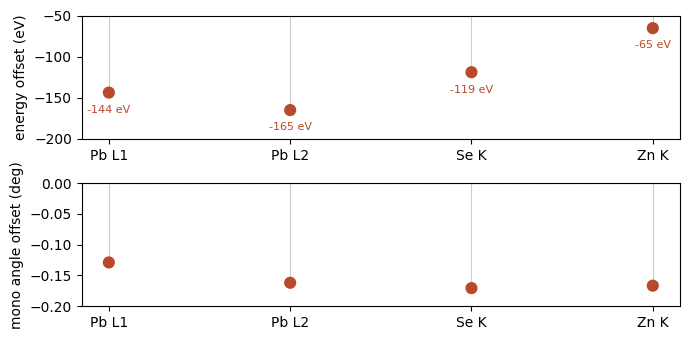

In [42]:
### results from Si311 
edges = [
    {'label': 'Pb L1', 'bragg': 13.9378, 'und': 16.9,  'uid': '71c03eb6', 'e_lit': 15.861},
    {'label': 'Pb L2', 'bragg': 14.584,  'und': 20.3,  'uid': '40d99a87', 'e_lit': 15.200},
    {'label': 'Se K',  'bragg': 17.573,  'und': 12.3,  'uid': 'a9e4d24b', 'e_lit': 12.658},
    {'label': 'Zn K',  'bragg': 23.242,  'und':  9.75, 'uid': 'afb28489', 'e_lit':  9.659},
]

for e in edges:
    e['mono'] = bragg_to_energy(e['bragg'], silicon=311)
    e['bragg_lit'] = energy_to_bragg(e['e_lit'], silicon=311)

labels  = [e['label'] for e in edges]
offsets_e = [(e['mono'] - e['e_lit']) * 1000 for e in edges]  # eV
offsets_a = [(e['bragg_lit'] - e['bragg']) for e in edges] # angle

fig, [ax0, ax1] = plt.subplots(2, 1, figsize=(7, 3.5))

colors = ['#b84a2a' if o < 0 else '#2a6eab' for o in offsets_a]

ax0.scatter(range(len(edges)), offsets_e, s=60, color=colors, zorder=3)
ax0.axhline(0, color='#888', linewidth=0.8, linestyle='--')
for i, (o, e) in enumerate(zip(offsets_e, edges)):
    ax0.plot([i, i], [0, o], color='#ccc', linewidth=0.8, zorder=2)
    ax0.text(i, o + (15 if o >= 0 else -15), f"{o:+.0f} eV", ha='center', va='bottom' if o >= 0 else 'top', fontsize=8, color=colors[i])
    print(f"{e['label']:6s}  bragg={e['bragg']:.4f}°  mono={e['mono']:.4f} keV  lit={e['e_lit']:.3f} keV  offset={o:+.1f} eV")
ax0.set_xticks(range(len(edges)))
ax0.set_xticklabels(labels, fontsize=10)
ax0.set_ylabel('energy offset (eV)', fontsize=10)
ax0.set_ylim([-200, -50])

ax1.scatter(range(len(edges)), offsets_a, s=60, color=colors, zorder=3)
ax1.axhline(0, color='#888', linewidth=0.8, linestyle='--')
for i, (oo, ee) in enumerate(zip(offsets_a, edges)):
    ax1.plot([i, i], [0, oo], color='#ccc', linewidth=0.8, zorder=2)
    # ax1.text(i, o + (15 if o >= 0 else -15), f"{o:+.0f} eV", ha='center', va='bottom' if o >= 0 else 'top', fontsize=8, color=colors[i])
    # print(f"{e['label']:6s}  bragg={e['bragg']:.4f}°  mono={e['mono']:.4f} keV  lit={e['e_lit']:.3f} keV  offset={o:+.1f} eV")
ax1.set_xticks(range(len(edges)))
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel('mono angle offset (deg)', fontsize=10)
ax1.set_ylim([-0.2, 0])


fig.tight_layout()
plt.show()

In [12]:
catalog = databroker.catalog["8idi_xpcs"]

runs_uids = list(catalog.search({}))

for uid in runs_uids[0:20]:
    run = catalog[uid]
    start = run.metadata["start"]
    t = start.get("time", 0)
    dt = datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S") if t else "?"
    print(
        uid[:],
        str(start.get("scan_id","?")).rjust(4),
        dt,
        start.get("plan_name","unknown"),
        start.get("detectors", []),
    )

af5e7ed0-930e-4901-92f4-9f2aeca9825c   13 2026-03-18 12:34:16 rel_scan ['tetramm1']
12e50399-5ee8-4ef3-b932-cced647b4804   12 2026-03-18 12:04:00 rel_scan ['tetramm1']
067a620f-e664-4951-b3b6-07fd0cf68e72   11 2026-03-18 11:36:40 rel_scan ['tetramm1']
04b1d821-0d5d-453e-b29a-ef513aad12fb   10 2026-03-18 11:06:43 rel_scan ['tetramm1']
e04fda54-d27f-474e-8645-ce960227b6a4    9 2026-03-18 11:05:44 rel_scan ['tetramm1']
f0c8b4c9-3644-49e3-afe1-8b33efbba5cf    8 2026-03-17 18:46:11 rel_scan ['tetramm1']
914f930f-f22d-4bcc-9eb7-f71d7952d264    7 2026-03-17 18:39:54 rel_scan ['tetramm1']
c10d5c04-d8e3-42a4-8fb5-2244f233fd13    6 2026-03-17 18:35:12 rel_scan ['tetramm1']
e456f4c5-56d2-4802-b78d-29044292288b    5 2026-03-17 18:31:04 rel_scan ['tetramm1']
ddaa8a81-339e-4b3d-a90d-e412556ff35d    4 2026-03-17 18:28:10 rel_scan ['tetramm1']
dee84b75-4782-4beb-a1ab-5f8750486e15    3 2026-03-17 18:23:58 rel_scan ['tetramm1']
1c145f68-f619-4090-9858-013fadf81476    2 2026-03-17 18:19:44 rel_scan ['tet

12e50399-5ee8-4ef3-b932-cced647b4804   12 2026-03-18 12:04:00 rel_scan ['tetramm1']


/home/beams/8IDIUSER/.conda/envs/8ide_bits_test/lib/python3.11/site-packages/databroker/intake_xarray_core/base.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/tmp/ipykernel_216841/3194353085.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_216841/3194353085.py:107: RuntimeWarning: divide by zero encountered in divide
  return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))
/tmp/ipykernel_216841/3194353085.py:107: RuntimeWarning: invalid value encountered in arcsin
  return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))


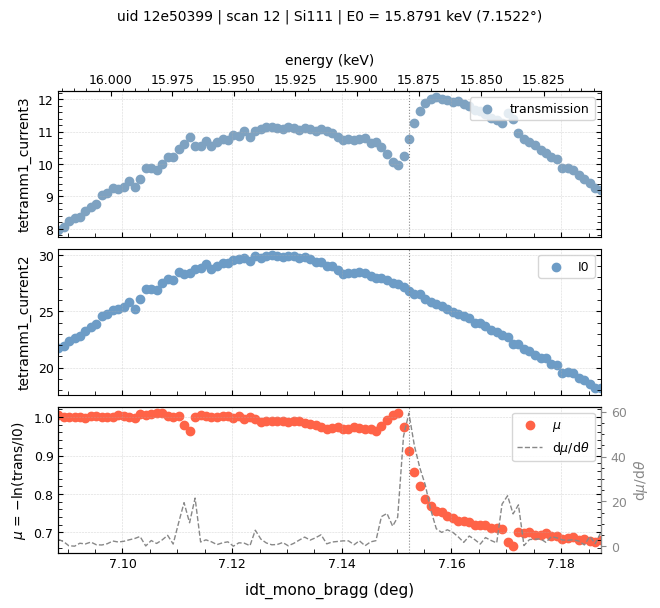

In [14]:
uid = '12e50399-5ee8-4ef3-b932-cced647b4804'
run = catalog[uid]
start = run.metadata["start"]
t = start.get("time", 0)
dt = datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S") if t else "?"
print(
    uid[:],
    str(start.get("scan_id","?")).rjust(4),
    dt,
    start.get("plan_name","unknown"),
    start.get("detectors", []),
    )

run = catalog[uid]
ds = run.primary.read()

# fig, axes = plot_transmission(ds, scan_axis='idt_mono_energy')
fig, axes = plot_transmission(ds, scan_axis='idt_mono_bragg', silicon=111)
plt.show()


In [38]:
print("Streams:", list(run))
bl = run.baseline.read()
print(bl)
# bl['idt_mono_bragg']


Streams: ['primary', 'baseline', 'label_start_motor']
<xarray.Dataset> Size: 272B
Dimensions:                              (time: 2)
Coordinates:
  * time                                 (time) float64 16B 1.774e+09 1.774e+09
Data variables: (12/16)
    idt_mono_bragg                       (time) float64 16B 23.08 23.33
    idt_mono_bragg_user_setpoint         (time) float64 16B 23.08 23.33
    idt_mono_xtal_gap                    (time) float64 16B 5.25 5.25
    idt_mono_xtal_gap_user_setpoint      (time) float64 16B 5.25 5.25
    idt_mono_flag                        (time) float64 16B 27.0 27.0
    idt_mono_flag_user_setpoint          (time) float64 16B 27.0 27.0
    ...                                   ...
    idt_mono_x_slide                     (time) float64 16B 51.19 51.19
    idt_mono_x_slide_user_setpoint       (time) float64 16B 51.19 51.19
    idt_mono_y_slide                     (time) float64 16B 5.3 5.3
    idt_mono_y_slide_user_setpoint       (time) float64 16B 5.3 5.3


In [ ]:
def plot_transmission(ds, scan_axis='idt_mono_bragg',
                      trans_ch='tetramm1_current3_mean_value',
                      i0_ch='tetramm1_current2_mean_value',
                      fluorescence='tetramm1_current1_mean_value',
                      silicon=311):

    theta = np.array(ds[scan_axis][1:])

    if scan_axis == 'idt_mono_bragg':
        x = theta
    else:
        x = np.array(ds[scan_axis][1:])

    scan_num = run.metadata["start"]["scan_id"]
    trans = np.array(ds[trans_ch][1:])
    I0    = np.array(ds[i0_ch][1:])
    fluor = np.array(ds[fluorescence])

    n = min(len(x), len(trans), len(I0))
    x, trans, I0 = x[:n], trans[:n], I0[:n]

    norm = trans / I0
    mu   = -np.log(norm)
    dmu  = np.abs(np.gradient(mu, x))

    e_edge_idx = np.argmax(np.abs(dmu))
    e_edge_deg = x[e_edge_idx]
    e_edge_kev = bragg_to_energy(e_edge_deg, silicon=silicon) if scan_axis == 'idt_mono_bragg' else None

    fig = plt.figure(figsize=(7, 6))
    gs  = fig.add_gridspec(3, 1, hspace=0.08)

    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    ax3 = ax2.twinx()

    if scan_axis == 'idt_mono_bragg':
        ax0_top = ax0.secondary_xaxis(
            'top',
            functions=(
                lambda t: bragg_to_energy(t, silicon=silicon),
                lambda e: energy_to_bragg(e, silicon=silicon)
            )
        )
        ax0_top.set_xlabel('energy (keV)', fontsize=10, labelpad=6)
        ax0_top.tick_params(axis='x', labelsize=9, direction='in')
        ax0_top.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax0.scatter(x, trans, color="#7ea2c1", label='transmission')
    ax1.scatter(x, I0, color="#6d9cc6", label='I0')
    ax2.scatter(x, mu, color='tomato',  label=r'$\mu$')
    ax3.plot(x, dmu, color='#888',    linewidth=1.0, linestyle='--', label=r'd$\mu$/d$\theta$')

    ax0.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
    ax1.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
    ax2.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')

    ax0.set_ylabel(trans_ch.split('_mean')[0], fontsize=10)
    ax1.set_ylabel(i0_ch.split('_mean')[0],    fontsize=10)
    ax2.set_ylabel(r'$\mu$ = $-\ln($trans/I0$)$', fontsize=10)
    ax3.set_ylabel(r'd$\mu$/d$\theta$', fontsize=10, color='#888')
    ax2.set_xlabel('idt_mono_bragg (deg)', fontsize=11, labelpad=8)

    lines  = ax2.collections[:] + ax3.get_lines()
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='best', fontsize=9)
    ax0.legend(loc='upper right', fontsize=9)
    ax1.legend(loc='upper right', fontsize=9)

    for ax in [ax0, ax1, ax2]:
        ax.tick_params(axis='both', labelsize=9, direction='in', top=False, right=True)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(which='minor', direction='in', right=True, length=3)
        ax.spines[:].set_linewidth(0.8)
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, zorder=0)
        ax.set_xlim(x.min(), x.max())

    ax3.tick_params(axis='y', labelsize=9, colors='#888')
    ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax3.spines['right'].set_linewidth(0.8)
    ax3.spines['right'].set_color('#888')

    plt.setp(ax0.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)

    title = f'uid {uid[:8]} | scan {scan_num} | Si{silicon}'
    if e_edge_kev is not None:
        title += f' | E0 = {e_edge_kev:.4f} keV ({e_edge_deg:.4f}°)'
    ax0.set_title(title, fontsize=10, pad=24, loc='center')

    fig.tight_layout()
    return fig, (ax0, ax1, ax2, ax3)


def bragg_to_energy(theta_deg, silicon=311):
    d = 3.1356 if silicon == 111 else 1.6375
    hc = 12.39842
    theta_rad = np.deg2rad(theta_deg)
    return hc / (2 * d * np.sin(theta_rad))


def energy_to_bragg(energy_keV, silicon=311):
    d = 3.1356 if silicon == 111 else 1.6375
    hc = 12.39842
    return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))

In [7]:
# def plot_transmission(ds, scan_axis='idt_mono_bragg',
#                       trans_ch='tetramm1_current3_mean_value',
#                       i0_ch='tetramm1_current2_mean_value',
#                       fluorescence='tetramm1_current1_mean_value',
#                       silicon=311):

#     theta = np.array(ds[scan_axis][1:])

#     if scan_axis == 'idt_mono_bragg':
#         x = theta
#     else:
#         x = np.array(ds[scan_axis][1:])

#     scan_num = run.metadata["start"]["scan_id"]
#     trans = np.array(ds[trans_ch][1:])
#     I0    = np.array(ds[i0_ch][1:])
#     fluor = np.array(ds[fluorescence][1:])

#     n = min(len(x), len(trans), len(I0))
#     x, trans, I0 = x[:n], trans[:n], I0[:n]

#     norm = trans / I0
#     mu   = -np.log(norm)
#     dmu  = np.abs(np.gradient(mu, x))

#     e_edge_idx = np.argmax(np.abs(dmu))
#     e_edge_deg = x[e_edge_idx]
#     e_edge_kev = bragg_to_energy(e_edge_deg, silicon=silicon) if scan_axis == 'idt_mono_bragg' else None

#     fig = plt.figure(figsize=(10, 8))
#     gs  = fig.add_gridspec(2, 2, hspace=0.08)

#     ax0 = fig.add_subplot(gs[0])
#     ax1 = fig.add_subplot(gs[1])
#     ax2 = fig.add_subplot(gs[2], sharex=ax0)
#     ax3 = ax2.twinx()
#     ax4 = fig.add_subplot(gs[3], sharex=ax1)

#     if scan_axis == 'idt_mono_bragg':
#         ax0_top = ax0.secondary_xaxis(
#             'top',
#             functions=(
#                 lambda t: bragg_to_energy(t, silicon=silicon),
#                 lambda e: energy_to_bragg(e, silicon=silicon)
#             )
#         )
#         ax0_top.set_xlabel('energy (keV)', fontsize=10, labelpad=6)
#         ax0_top.tick_params(axis='x', labelsize=9, direction='in')
#         ax0_top.xaxis.set_minor_locator(ticker.AutoMinorLocator())

#     ax0.scatter(x, trans, color="#7ea2c1", label='transmission')
#     ax1.scatter(x, I0, color="#6d9cc6", label='I0')
#     ax2.scatter(x, mu, color='tomato',  label=r'$\mu$')
#     ax3.plot(x, dmu, color='#888', linewidth=1.0, linestyle='--', label=r'd$\mu$/d$\theta$')
#     ax4.scatter(x, fluor/I0, color="#c6a46d", label='fluorescence')

#     ax0.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
#     ax1.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
#     ax2.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')

#     ax0.set_ylabel(trans_ch.split('_mean')[0], fontsize=10)
#     ax1.set_ylabel(i0_ch.split('_mean')[0],    fontsize=10)
#     ax2.set_ylabel(r'$\mu$ = $-\ln($trans/I0$)$', fontsize=10)
#     ax3.set_ylabel(r'd$\mu$/d$\theta$', fontsize=10, color='#888')
#     ax2.set_xlabel('idt_mono_bragg (deg)', fontsize=11, labelpad=8)

#     lines  = ax2.collections[:] + ax3.get_lines()
#     labels = [l.get_label() for l in lines]
#     ax2.legend(lines, labels, loc='best', fontsize=9)
#     ax0.legend(loc='upper right', fontsize=9)
#     ax1.legend(loc='upper right', fontsize=9)

#     for ax in [ax0, ax1, ax2]:
#         ax.tick_params(axis='both', labelsize=9, direction='in', top=False, right=True)
#         ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
#         ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
#         ax.tick_params(which='minor', direction='in', right=True, length=3)
#         ax.spines[:].set_linewidth(0.8)
#         ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, zorder=0)
#         ax.set_xlim(x.min(), x.max())

#     ax3.tick_params(axis='y', labelsize=9, colors='#888')
#     ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
#     ax3.spines['right'].set_linewidth(0.8)
#     ax3.spines['right'].set_color('#888')

#     plt.setp(ax0.get_xticklabels(), visible=False)
#     plt.setp(ax1.get_xticklabels(), visible=False)

#     title = f'uid {uid[:8]} | scan {scan_num}'
#     if e_edge_kev is not None:
#         title += f' | E0 = {e_edge_kev:.4f} keV ({e_edge_deg:.4f}°)'
#     ax0.set_title(title, fontsize=10, pad=24, loc='center')

#     fig.tight_layout()
#     return fig, (ax0, ax1, ax2, ax3)


# def bragg_to_energy(theta_deg, silicon=311):
#     d = 3.1356 if silicon == 111 else 1.6375
#     hc = 12.39842
#     theta_rad = np.deg2rad(theta_deg)
#     return hc / (2 * d * np.sin(theta_rad))


# def energy_to_bragg(energy_keV, silicon=311):
#     d = 3.1356 if silicon == 111 else 1.6375
#     hc = 12.39842
#     return np.rad2deg(np.arcsin(hc / (2 * d * energy_keV)))